# Задача 9. Hand-crafted graph features

- Найти или сгенерировать набор данных для бинарной классификации графов.
- Реализовать функцию `shortest_path_kernel(train_graphs, test_graphs)`, которая принимает тренировочный и тестовые наборы, а возвращает пару `K_train, K_test`
  - Опишите графы с помощью вектора из количества кратчайших путей различной длины
  - Для вычисления длин кратчайших путей можно использовать `nx.shortest_path_length(G)`
  - Ядровая функция для сравнения двух графов - скалярное произведение их двух векторов
  - `K_train` - матрица из ядровых функций для сравнения тренировочных графов между собой
  - `K_test` - матрица из ядровых функций для сравнения тестовых графов с тренировочными
 - Используя реализованное ядро обучите модель SVC, подберите гиперпараметры, вычислите различные метрики качества
 - (+5 баллов) Также реализовать Weisfeiler-Lehman Kernel и обучить классификатор с ним, сравнить результаты.

# Подготовка окружения

In [45]:
import random
import time
import tqdm
import networkx as nx
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import f1_score, accuracy_score, precision_score, classification_report
from collections import Counter

SEED = 42
GRAPH_AMOUNT = 1000
MIN_NODES_AMOUNT = 10
MAX_NODES_AMOUNT = 20
DISCON_GRAPH_COMPONENTS_MIN = 2
DISCON_GRAPH_COMPONENTS_MAX = 5

# Датасет
- Класс 0 (несвязные графы): графы, состоящие из нескольких компонент связности, например, двух случайных деревьев.
- Класс 1 (связные графы): графы, в которых гарантируется наличие пути между любой парой вершин

In [46]:
def generate_random_tree(n):
    G = nx.Graph()
    G.add_nodes_from(range(n))
    for i in range(1, n):
        parent = random.randint(0, i - 1)
        G.add_edge(i, parent)
    return G

In [47]:
def generate_connected_graph(n):
    G = generate_random_tree(n)

    possible_edges = [
        (u, v) for u in range(n) for v in range(u + 1, n)
        if not G.has_edge(u, v)
    ]
    random.shuffle(possible_edges)

    num_extra_edges = random.randint(0, n // 2)
    for u, v in possible_edges[:num_extra_edges]:
        G.add_edge(u, v)

    return G

def generate_disconnected_graph(n):
    k = random.randint(DISCON_GRAPH_COMPONENTS_MIN, min(n, DISCON_GRAPH_COMPONENTS_MAX))

    splits = []
    remaining = n
    for i in range(k - 1):
        part = random.randint(1, remaining - (k - i - 1))
        splits.append(part)
        remaining -= part
    splits.append(remaining)

    components = []
    node_offset = 0
    for size in splits:
        component_type = random.choice(["tree", "path", "cycle", "isolated"])

        if size == 1 or component_type == "isolated":
            G = nx.empty_graph(size)
        elif component_type == "tree":
            G = generate_random_tree(size)
        elif component_type == "path":
            G = nx.path_graph(size)
        elif component_type == "cycle":
            G = nx.cycle_graph(size)

        G = nx.relabel_nodes(G, lambda x: x + node_offset)
        node_offset += size
        components.append(G)

    G_total = nx.Graph()
    for comp in components:
        G_total = nx.union(G_total, comp)

    return G_total


def generate_graph_dataset(n_graphs=GRAPH_AMOUNT, min_nodes=MIN_NODES_AMOUNT, max_nodes=MAX_NODES_AMOUNT, seed=SEED):
    random.seed(seed)

    graphs = []
    y = []

    half = n_graphs // 2

    for _ in range(half):
        n = random.randint(min_nodes, max_nodes)
        G = generate_connected_graph(n)
        graphs.append(G)
        y.append(1)

    for _ in range(n_graphs - half):
        n = random.randint(min_nodes, max_nodes)
        G = generate_disconnected_graph(n)
        graphs.append(G)
        y.append(0)

    return list(graphs), list(y)

In [48]:
graphs, y = generate_graph_dataset()

In [49]:
train_graphs, test_graphs, y_train, y_test = train_test_split(
    graphs, y, test_size=0.3, random_state=SEED, stratify=y
)

# Визуализация графов

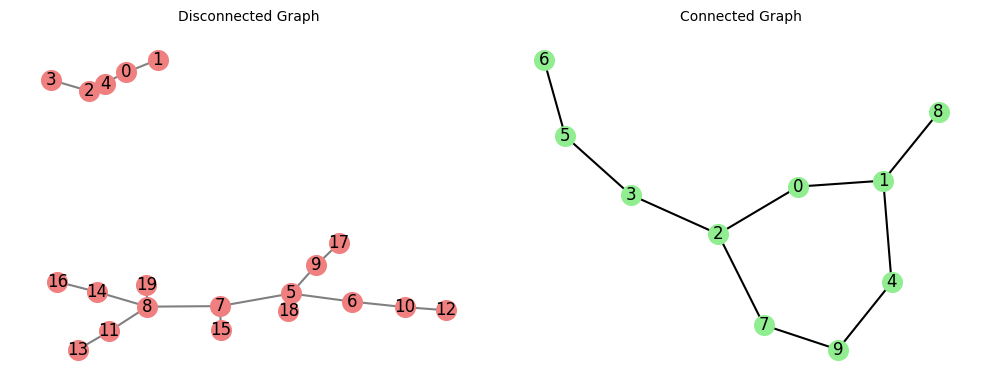

In [50]:
graphs = [
    ("Disconnected", train_graphs[y_train.index(0)]),
    ("Connected", train_graphs[y_train.index(1)])
]

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
pos = nx.spring_layout(graphs[0][1], seed=SEED)
nx.draw(
    graphs[0][1], 
    pos=pos,
    with_labels=True,
    node_color='lightcoral',
    edge_color='gray',
    node_size=200,
    width=1.5
)
plt.title("Disconnected Graph", fontsize=10)
plt.subplot(1, 2, 2)
pos = nx.spring_layout(graphs[1][1], seed=42)
nx.draw(
    graphs[1][1],
    pos=pos,
    with_labels=True,
    node_color='lightgreen',
    edge_color='black',
    node_size=200,
    width=1.5
)
plt.title("Connected Graph", fontsize=10)
plt.tight_layout()
plt.savefig('connected_vs_disconnected.png', dpi=300, bbox_inches='tight')
plt.show()

# Shortest path kernel

In [51]:
class ShortestPathKernel:
    def __init__(self, max_path_len=10):
        self.max_path_len = max_path_len

    def _compute_shortest_paths(self, G):
        return dict(nx.shortest_path_length(G))

    def _extract_path_length_features(self, shortest_paths):
        path_length_counts = Counter()
        for source, targets in shortest_paths.items():
            for target, distance in targets.items():
                if source < target and distance <= self.max_path_len:
                    path_length_counts[distance] += 1

        return np.array([path_length_counts.get(i, 0) for i in range(1, self.max_path_len + 1)])

    def _graph_to_feature_vector(self, G):
        shortest_paths = self._compute_shortest_paths(G)
        return self._extract_path_length_features(shortest_paths)

    def fit_transform(self, train_graphs):
        return np.array([self._graph_to_feature_vector(g) for g in train_graphs])

    def transform(self, test_graphs, train_vectors):
        test_vectors = np.array([self._graph_to_feature_vector(g) for g in test_graphs])
        return np.dot(test_vectors, train_vectors.T)

    def compute_kernel(self, train_graphs, test_graphs):
        train_features = self.fit_transform(train_graphs)
        test_features = self.transform(test_graphs, train_features)
        train_kernel = np.dot(train_features, train_features.T)
        return train_kernel, test_features

# Weisfeiler-Lehman Kernel

In [52]:
class WeisfeilerLehmanKernel:
    def __init__(self, h=3):
        self.h = h
        self.vocab = {}

    def _initialize_labels(self, G):
        return {v: str(G.nodes[v].get("label", G.degree(v))) for v in G.nodes}

    def _update_labels(self, labels, G):
        new_labels = {}
        for v in G.nodes:
            neigh_lab = sorted(labels[u] for u in G.neighbors(v))
            new_lab = labels[v] + "|" + "|".join(neigh_lab)
            new_labels[v] = new_lab
        return new_labels

    def _get_subtree_vector(self, G):
        labels = self._initialize_labels(G)
        path_length_counts = Counter(labels.values())

        for _ in range(self.h):
            labels = self._update_labels(labels, G)
            path_length_counts.update(labels.values())

        return path_length_counts

    def _build_vocab(self, train_graphs, test_graphs):
        all_graphs = train_graphs + test_graphs
        for g in all_graphs:
            feature_set = self._get_subtree_vector(g)
            for label in feature_set:
                if label not in self.vocab:
                    self.vocab[label] = len(self.vocab)

    def _dict_to_vector(self, feature_set):
        vector = np.zeros(len(self.vocab), dtype=np.float32)
        for label, count in feature_set.items():
            vector[self.vocab[label]] = count
        return vector

    def fit_transform(self, train_graphs, test_graphs):
        self._build_vocab(train_graphs, test_graphs)

        train_feature_vectors = [self._get_subtree_vector(g) for g in train_graphs]
        return np.array([self._dict_to_vector(f) for f in train_feature_vectors])

    def transform(self, test_graphs, train_vectors):
        test_feature_vectors = [self._get_subtree_vector(g) for g in test_graphs]
        test_vectors = np.array([self._dict_to_vector(f) for f in test_feature_vectors])
        return np.dot(test_vectors, train_vectors.T)

    def compute_kernel(self, train_graphs, test_graphs):
        train_vectors = self.fit_transform(train_graphs, test_graphs)
        test_kernel = self.transform(test_graphs, train_vectors)
        train_kernel = np.dot(train_vectors, train_vectors.T)
        return train_kernel, test_kernel

# Обучение и подбор

In [53]:
shortest_path_kernel = ShortestPathKernel()
train_kernel_matrix, test_kernel_matrix = shortest_path_kernel.compute_kernel(
    train_graphs, 
    test_graphs
)

In [54]:
graph_classifier = SVC(
    kernel="precomputed",
    C=1.0,
    random_state=SEED
)
graph_classifier.fit(train_kernel_matrix, y_train)
test_predictions = graph_classifier.predict(test_kernel_matrix)
print(classification_report(
    y_test,
    test_predictions,
    digits=4
))

              precision    recall  f1-score   support

           0     0.9586    0.9267    0.9424       150
           1     0.9290    0.9600    0.9443       150

    accuracy                         0.9433       300
   macro avg     0.9438    0.9433    0.9433       300
weighted avg     0.9438    0.9433    0.9433       300



In [55]:
wl_kernel = WeisfeilerLehmanKernel()
train_kernel_matrix, test_kernel_matrix = wl_kernel.compute_kernel(
    train_graphs, 
    test_graphs
)

In [56]:
graph_classifier = SVC(
    kernel="precomputed",
    C=1.0,
    random_state=SEED
)
graph_classifier.fit(train_kernel_matrix, y_train)
test_predictions = graph_classifier.predict(test_kernel_matrix)
print(classification_report(
    y_test, 
    test_predictions, 
    digits=4
))

              precision    recall  f1-score   support

           0     1.0000    0.9667    0.9831       150
           1     0.9677    1.0000    0.9836       150

    accuracy                         0.9833       300
   macro avg     0.9839    0.9833    0.9833       300
weighted avg     0.9839    0.9833    0.9833       300



In [57]:
def compute_kernel_with_params(train_graphs, test_graphs, max_path_len):
    shortest_path_kernel = ShortestPathKernel(max_path_len=max_path_len)
    train_kernel, test_kernel = shortest_path_kernel.compute_kernel(train_graphs, test_graphs)
    return train_kernel, test_kernel

In [58]:
def run_grid_search(param_grid, train_graphs, test_graphs, y_train, y_test):
    grid_search_results = []
    
    param_combinations = [
        (max_len, c_val)
        for max_len in param_grid['max_path_len']
        for c_val in param_grid['C']
    ]
    
    start_time = time.time()
    
    for max_path_len, C in tqdm.tqdm(param_combinations, desc="Grid Search Progress"):
        K_train, K_test = compute_kernel_with_params(
            train_graphs, 
            test_graphs, 
            max_path_len
        )
        
        model = SVC(
            kernel="precomputed",
            C=C,
            random_state=42
        )
        model.fit(K_train, y_train)
        y_pred = model.predict(K_test)
        
        grid_search_results.append({
            "max_path_len": max_path_len,
            "C": C,
            "accuracy": accuracy_score(y_test, y_pred),
            "precision": precision_score(y_test, y_pred, zero_division=0),
            "f1": f1_score(y_test, y_pred, zero_division=0),
        })
    
    results_df = pd.DataFrame(grid_search_results)
    
    search_duration = time.time() - start_time
    print(f"\nGrid search completed in {search_duration:.2f} seconds")
    
    return results_df.sort_values(by="accuracy", ascending=False)

In [59]:
param_grid = {
    'max_path_len': [2, 4, 6, 8, 10],
    'C': [0.1, 1, 5, 10, 50]
}

results = run_grid_search(
    param_grid=param_grid,
    train_graphs=train_graphs,
    test_graphs=test_graphs,
    y_train=y_train,
    y_test=y_test
)

print("Top 3 configurations:")
print(results.head(3))

Grid Search Progress: 100%|██████████| 25/25 [00:03<00:00,  6.30it/s]


Grid search completed in 3.97 seconds
Top 3 configurations:
    max_path_len    C  accuracy  precision        f1
12             6  5.0      0.95   0.924528  0.951456
20            10  0.1      0.95   0.924528  0.951456
15             8  0.1      0.95   0.924528  0.951456


# Заключение

Метрики на задаче бинарной классификации показывают высокие результаты для обоих ядер, но Weisfeiler–Lehman Kernel стабильно показывает немного лучшие результаты по сравнению с Shortest-Path Kernel.